# CS229 Lecture 5: GDA & Naive Bayes
## Practice & Revision Notebook

This notebook covers:
1. **Discriminative vs. Generative** — conceptual comparison
2. **Gaussian Discriminant Analysis (GDA)** — full implementation & visualization
3. **Naive Bayes** — implementation for text/spam classification
4. **Laplace Smoothing** — handling unseen features
5. **GDA vs. Logistic Regression** — empirical comparison
6. **Exercises**

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.stats import multivariate_normal
from sklearn.datasets import make_classification, make_blobs, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('All imports successful!')

All imports successful!


---
# Part 1: Discriminative vs. Generative Learning Algorithms

## Conceptual Overview

| Aspect | Discriminative | Generative |
|--------|---------------|------------|
| **Models** | $p(y \mid x)$ directly | $p(x \mid y)$ and $p(y)$, then uses Bayes' rule |
| **Approach** | Learn the decision boundary | Learn what each class "looks like" |
| **Examples** | Logistic Regression, Perceptron, SVM | GDA, Naive Bayes, HMMs |
| **Prediction** | Direct: $\arg\max_y p(y \mid x)$ | Via Bayes: $\arg\max_y p(x \mid y) p(y)$ |
| **Data efficiency** | Needs more data | Can work with less data (if assumptions hold) |
| **Robustness** | More robust to model misspecification | Can suffer if assumptions are wrong |

### Bayes' Rule (the engine of generative models):

$$p(y \mid x) = \frac{p(x \mid y) \cdot p(y)}{p(x)} = \frac{p(x \mid y) \cdot p(y)}{\sum_{y'} p(x \mid y') \cdot p(y')}$$

For classification, we only need:
$$\arg\max_y \ p(y \mid x) = \arg\max_y \ p(x \mid y) \cdot p(y)$$

(The denominator $p(x)$ is the same for all classes, so it doesn't affect the argmax.)

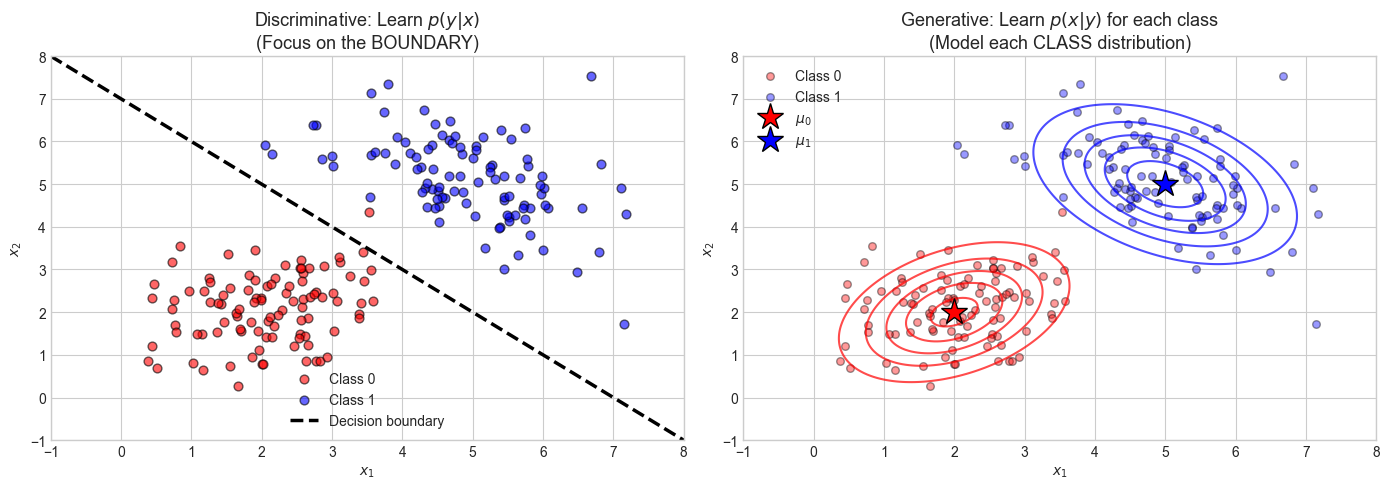

Left: Discriminative — focuses on finding what SEPARATES the classes
Right: Generative — focuses on modeling what each class LOOKS LIKE


In [2]:
# Visual intuition: Discriminative vs Generative

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

np.random.seed(42)
# Generate two classes from 2D Gaussians
n = 100
class0 = np.random.multivariate_normal([2, 2], [[0.8, 0.3], [0.3, 0.8]], n)
class1 = np.random.multivariate_normal([5, 5], [[1.0, -0.4], [-0.4, 1.0]], n)

# --- Discriminative View ---
ax = axes[0]
ax.scatter(class0[:, 0], class0[:, 1], c='red', alpha=0.6, edgecolors='k', s=40, label='Class 0')
ax.scatter(class1[:, 0], class1[:, 1], c='blue', alpha=0.6, edgecolors='k', s=40, label='Class 1')

# Draw a decision boundary line
x_line = np.linspace(-1, 8, 100)
y_line = -x_line + 7  # approximate boundary
ax.plot(x_line, y_line, 'k--', linewidth=2.5, label='Decision boundary')
ax.set_xlim(-1, 8)
ax.set_ylim(-1, 8)
ax.set_title('Discriminative: Learn $p(y|x)$\n(Focus on the BOUNDARY)', fontsize=13)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.legend()

# --- Generative View ---
ax = axes[1]

# Plot contours of the class-conditional Gaussians
x_grid = np.linspace(-1, 8, 200)
y_grid = np.linspace(-1, 8, 200)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
pos = np.dstack((X_grid, Y_grid))

rv0 = multivariate_normal([2, 2], [[0.8, 0.3], [0.3, 0.8]])
rv1 = multivariate_normal([5, 5], [[1.0, -0.4], [-0.4, 1.0]])

ax.contour(X_grid, Y_grid, rv0.pdf(pos), levels=5, colors='red', alpha=0.7)
ax.contour(X_grid, Y_grid, rv1.pdf(pos), levels=5, colors='blue', alpha=0.7)
ax.scatter(class0[:, 0], class0[:, 1], c='red', alpha=0.4, edgecolors='k', s=30, label='Class 0')
ax.scatter(class1[:, 0], class1[:, 1], c='blue', alpha=0.4, edgecolors='k', s=30, label='Class 1')

# Mark means
ax.plot(2, 2, 'r*', markersize=20, markeredgecolor='k', label='$\\mu_0$')
ax.plot(5, 5, 'b*', markersize=20, markeredgecolor='k', label='$\\mu_1$')

ax.set_xlim(-1, 8)
ax.set_ylim(-1, 8)
ax.set_title('Generative: Learn $p(x|y)$ for each class\n(Model each CLASS distribution)', fontsize=13)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

print("Left: Discriminative — focuses on finding what SEPARATES the classes")
print("Right: Generative — focuses on modeling what each class LOOKS LIKE")

---
# Part 2: Gaussian Discriminant Analysis (GDA)

## 2.1 Model

GDA is a **generative** model for **continuous features** with the following assumptions:

$$y \sim \text{Bernoulli}(\phi)$$
$$x \mid y = 0 \sim \mathcal{N}(\mu_0, \Sigma)$$
$$x \mid y = 1 \sim \mathcal{N}(\mu_1, \Sigma)$$

Key points:
- Each class has its **own mean** ($\mu_0$, $\mu_1$)
- Both classes share the **same covariance** $\Sigma$ → produces a **linear** decision boundary
- If $\Sigma$ were different per class → **Quadratic** Discriminant Analysis (QDA)

## 2.2 MLE Solutions (Closed-Form)

$$\phi = \frac{1}{m} \sum_{i=1}^{m} \mathbb{1}\{y^{(i)} = 1\}$$

$$\mu_0 = \frac{\sum_{i} \mathbb{1}\{y^{(i)} = 0\} \cdot x^{(i)}}{\sum_{i} \mathbb{1}\{y^{(i)} = 0\}} \qquad \mu_1 = \frac{\sum_{i} \mathbb{1}\{y^{(i)} = 1\} \cdot x^{(i)}}{\sum_{i} \mathbb{1}\{y^{(i)} = 1\}}$$

$$\Sigma = \frac{1}{m} \sum_{i=1}^{m} (x^{(i)} - \mu_{y^{(i)}})(x^{(i)} - \mu_{y^{(i)}})^T$$

In [3]:
class GaussianDiscriminantAnalysis:
    """
    Gaussian Discriminant Analysis (GDA) — a generative learning algorithm.
    
    Assumes:
        - y ~ Bernoulli(phi)
        - x|y=0 ~ N(mu_0, Sigma)
        - x|y=1 ~ N(mu_1, Sigma)
        - Shared covariance matrix (linear decision boundary)
    """
    
    def __init__(self):
        self.phi = None       # p(y=1)
        self.mu_0 = None      # mean of class 0
        self.mu_1 = None      # mean of class 1
        self.Sigma = None     # shared covariance matrix
        self.Sigma_inv = None # inverse of covariance matrix
    
    def fit(self, X, y):
        """
        Fit GDA using Maximum Likelihood Estimation (closed-form solutions).
        """
        m, n = X.shape
        
        # 1. phi = fraction of positive examples
        self.phi = np.mean(y == 1)
        
        # 2. mu_0 = mean of class 0 examples
        self.mu_0 = np.mean(X[y == 0], axis=0)
        
        # 3. mu_1 = mean of class 1 examples
        self.mu_1 = np.mean(X[y == 1], axis=0)
        
        # 4. Sigma = pooled covariance matrix
        # For each sample, subtract the mean of its class, then compute covariance
        X_centered = X.copy()
        X_centered[y == 0] -= self.mu_0
        X_centered[y == 1] -= self.mu_1
        self.Sigma = (X_centered.T @ X_centered) / m
        
        # Precompute inverse for predictions
        self.Sigma_inv = np.linalg.inv(self.Sigma)
        
        print("GDA Parameters Learned:")
        print(f"  phi (prior p(y=1)):  {self.phi:.4f}")
        print(f"  mu_0 (class 0 mean): {self.mu_0}")
        print(f"  mu_1 (class 1 mean): {self.mu_1}")
        print(f"  Sigma shape:         {self.Sigma.shape}")
        
        return self
    
    def _multivariate_gaussian(self, x, mu):
        """Compute p(x | y) = N(x; mu, Sigma)."""
        n = len(mu)
        diff = x - mu
        exponent = -0.5 * diff @ self.Sigma_inv @ diff
        normalizer = 1 / (np.sqrt((2 * np.pi) ** n * np.linalg.det(self.Sigma)))
        return normalizer * np.exp(exponent)
    
    def predict_proba(self, X):
        """Compute p(y=1 | x) using Bayes' rule."""
        probas = np.zeros(X.shape[0])
        
        for i in range(X.shape[0]):
            # p(x | y=0) * p(y=0)
            p_x_given_0 = self._multivariate_gaussian(X[i], self.mu_0)
            p_y_0 = 1 - self.phi
            
            # p(x | y=1) * p(y=1)
            p_x_given_1 = self._multivariate_gaussian(X[i], self.mu_1)
            p_y_1 = self.phi
            
            # Bayes' rule: p(y=1 | x) = p(x|y=1)*p(y=1) / [p(x|y=0)*p(y=0) + p(x|y=1)*p(y=1)]
            numerator = p_x_given_1 * p_y_1
            denominator = p_x_given_0 * p_y_0 + p_x_given_1 * p_y_1
            
            probas[i] = numerator / (denominator + 1e-300)
        
        return probas
    
    def predict(self, X):
        """Predict class labels."""
        return (self.predict_proba(X) >= 0.5).astype(int)
    
    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

print("GDA class defined!")

GDA class defined!


## 2.3 Training & Visualizing GDA

In [4]:
# Generate 2D binary classification data
np.random.seed(42)
n_per_class = 150

# Class 0: Gaussian centered at (-2, -2)
X_class0 = np.random.multivariate_normal([-2, -2], [[1.5, 0.5], [0.5, 1.5]], n_per_class)
y_class0 = np.zeros(n_per_class)

# Class 1: Gaussian centered at (2, 2)
X_class1 = np.random.multivariate_normal([2, 2], [[1.5, 0.5], [0.5, 1.5]], n_per_class)
y_class1 = np.ones(n_per_class)

X_gda = np.vstack([X_class0, X_class1])
y_gda = np.concatenate([y_class0, y_class1])

# Shuffle
shuffle_idx = np.random.permutation(len(y_gda))
X_gda = X_gda[shuffle_idx]
y_gda = y_gda[shuffle_idx]

# Train GDA
gda = GaussianDiscriminantAnalysis()
gda.fit(X_gda, y_gda)

print(f"\nTraining accuracy: {gda.accuracy(X_gda, y_gda):.4f}")

GDA Parameters Learned:
  phi (prior p(y=1)):  0.5000
  mu_0 (class 0 mean): [-1.98217704 -1.94970179]
  mu_1 (class 1 mean): [2.02673261 1.94828344]
  Sigma shape:         (2, 2)

Training accuracy: 0.9767


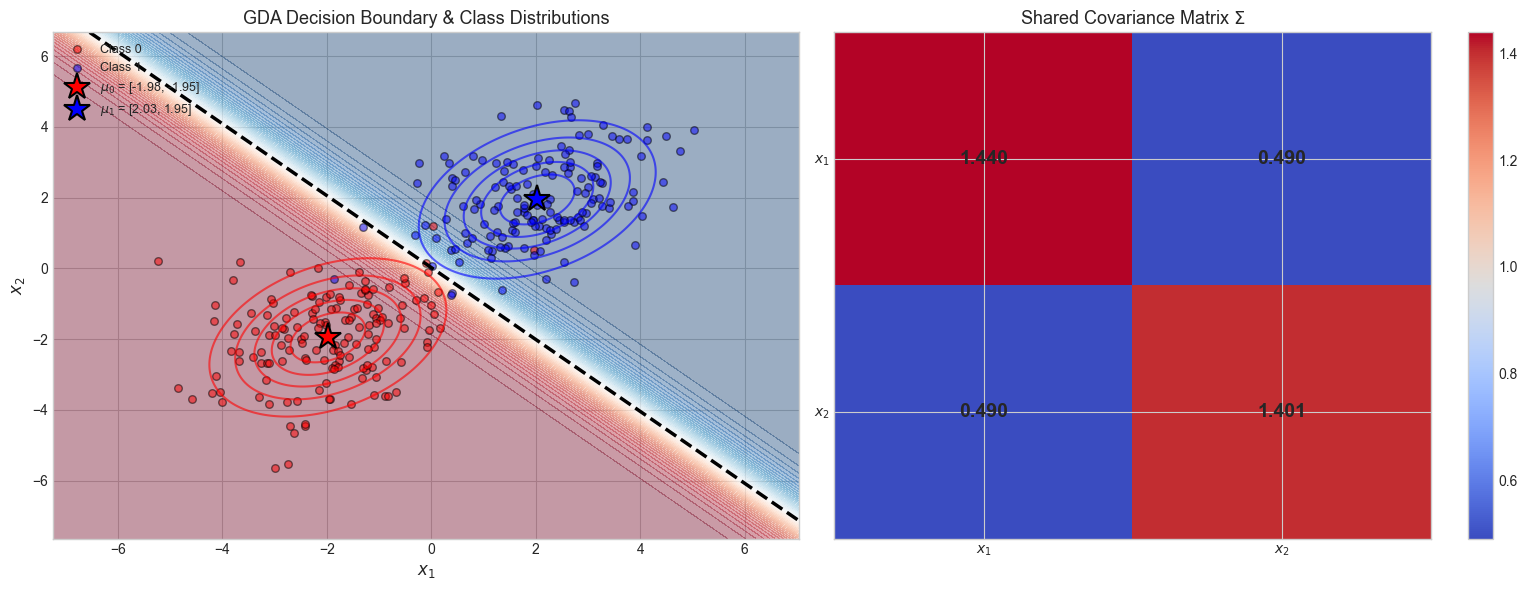

In [5]:
def plot_gda(X, y, model, title='GDA Decision Boundary & Class Distributions'):
    """Comprehensive GDA visualization."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- Plot 1: Decision boundary with Gaussian contours ---
    ax = axes[0]
    
    # Decision boundary via mesh
    x_min, x_max = X[:, 0].min() - 2, X[:, 0].max() + 2
    y_min, y_max = X[:, 1].min() - 2, X[:, 1].max() + 2
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict_proba(grid).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.4)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2.5, linestyles='--')
    
    # Gaussian contours for each class
    pos = np.dstack((xx, yy))
    rv0 = multivariate_normal(model.mu_0, model.Sigma)
    rv1 = multivariate_normal(model.mu_1, model.Sigma)
    ax.contour(xx, yy, rv0.pdf(pos), levels=5, colors='red', alpha=0.6, linewidths=1.5)
    ax.contour(xx, yy, rv1.pdf(pos), levels=5, colors='blue', alpha=0.6, linewidths=1.5)
    
    # Data points
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='red', alpha=0.5, edgecolors='k', s=30, label='Class 0')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', alpha=0.5, edgecolors='k', s=30, label='Class 1')
    
    # Means
    ax.plot(*model.mu_0, 'r*', markersize=20, markeredgecolor='k', markeredgewidth=1.5, label=f'$\\mu_0$ = [{model.mu_0[0]:.2f}, {model.mu_0[1]:.2f}]')
    ax.plot(*model.mu_1, 'b*', markersize=20, markeredgecolor='k', markeredgewidth=1.5, label=f'$\\mu_1$ = [{model.mu_1[0]:.2f}, {model.mu_1[1]:.2f}]')
    
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(loc='upper left', fontsize=9)
    
    # --- Plot 2: Covariance matrix heatmap ---
    ax2 = axes[1]
    im = ax2.imshow(model.Sigma, cmap='coolwarm', aspect='auto')
    for i in range(model.Sigma.shape[0]):
        for j in range(model.Sigma.shape[1]):
            ax2.text(j, i, f'{model.Sigma[i, j]:.3f}', ha='center', va='center', fontsize=14, fontweight='bold')
    ax2.set_title('Shared Covariance Matrix $\\Sigma$', fontsize=13)
    ax2.set_xticks(range(model.Sigma.shape[1]))
    ax2.set_yticks(range(model.Sigma.shape[0]))
    ax2.set_xticklabels([f'$x_{i+1}$' for i in range(model.Sigma.shape[1])])
    ax2.set_yticklabels([f'$x_{i+1}$' for i in range(model.Sigma.shape[0])])
    plt.colorbar(im, ax=ax2)
    
    plt.tight_layout()
    plt.show()

plot_gda(X_gda, y_gda, gda)

## 2.4 Key Insight: GDA → Logistic Regression

When the class-conditional distributions are Gaussian with a **shared covariance matrix**, the posterior $p(y=1|x)$ can be shown to take the **logistic (sigmoid) form**:

$$p(y=1|x) = \frac{1}{1 + \exp(-\theta^T x)}$$

where $\theta$ is a function of $\mu_0, \mu_1, \Sigma, \phi$.

This means:
- **GDA is a special case** that implies logistic regression
- **Logistic regression is more general** — it doesn't require Gaussian assumptions
- GDA makes a **stronger** assumption → can be more data-efficient when the assumption holds

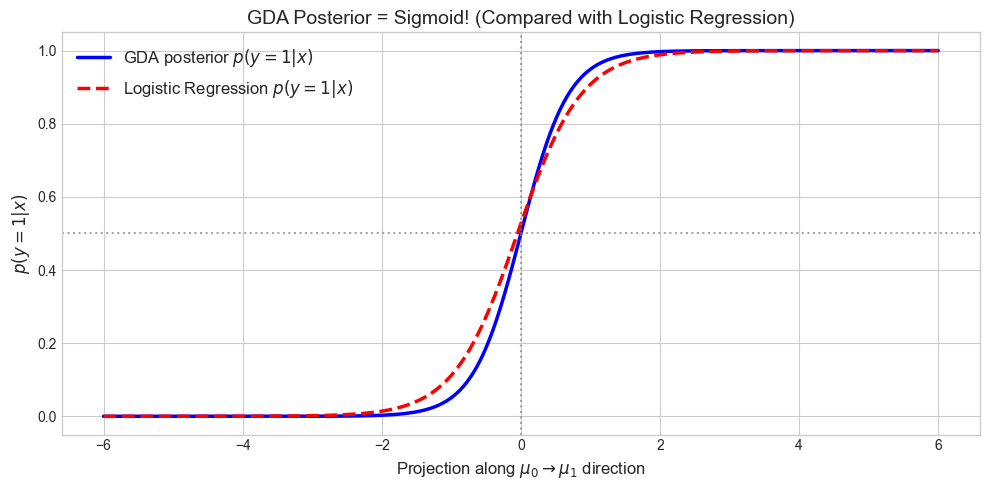

Notice: The GDA posterior and logistic regression produce nearly identical sigmoid curves!
This confirms: GDA implies logistic regression.


In [6]:
# Demonstrate: GDA posterior looks like a sigmoid

# Create a 1D slice through the feature space (along the line connecting mu_0 and mu_1)
direction = gda.mu_1 - gda.mu_0
direction = direction / np.linalg.norm(direction)

# Project data onto this direction
t_range = np.linspace(-6, 6, 500)
points = np.array([gda.mu_0 + t * direction + (gda.mu_1 - gda.mu_0) / 2 for t in t_range])
probas = gda.predict_proba(points)

# Also fit logistic regression for comparison
from sklearn.linear_model import LogisticRegression
lr_sklearn = LogisticRegression(max_iter=1000)
lr_sklearn.fit(X_gda, y_gda)
lr_probas = lr_sklearn.predict_proba(points)[:, 1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_range, probas, 'b-', linewidth=2.5, label='GDA posterior $p(y=1|x)$')
ax.plot(t_range, lr_probas, 'r--', linewidth=2.5, label='Logistic Regression $p(y=1|x)$')
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.7)
ax.axvline(x=0, color='gray', linestyle=':', alpha=0.7)
ax.set_xlabel('Projection along $\\mu_0 \\to \\mu_1$ direction', fontsize=12)
ax.set_ylabel('$p(y=1|x)$', fontsize=12)
ax.set_title('GDA Posterior = Sigmoid! (Compared with Logistic Regression)', fontsize=14)
ax.legend(fontsize=12)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

print("Notice: The GDA posterior and logistic regression produce nearly identical sigmoid curves!")
print("This confirms: GDA implies logistic regression.")

## 2.5 GDA vs. Logistic Regression: Sample Efficiency

**Theory predicts:**
- GDA should be better with **small datasets** (when Gaussian assumptions ≈ hold)
- Logistic Regression should be better **asymptotically** (with large datasets) and when assumptions are violated

Let's verify this empirically!

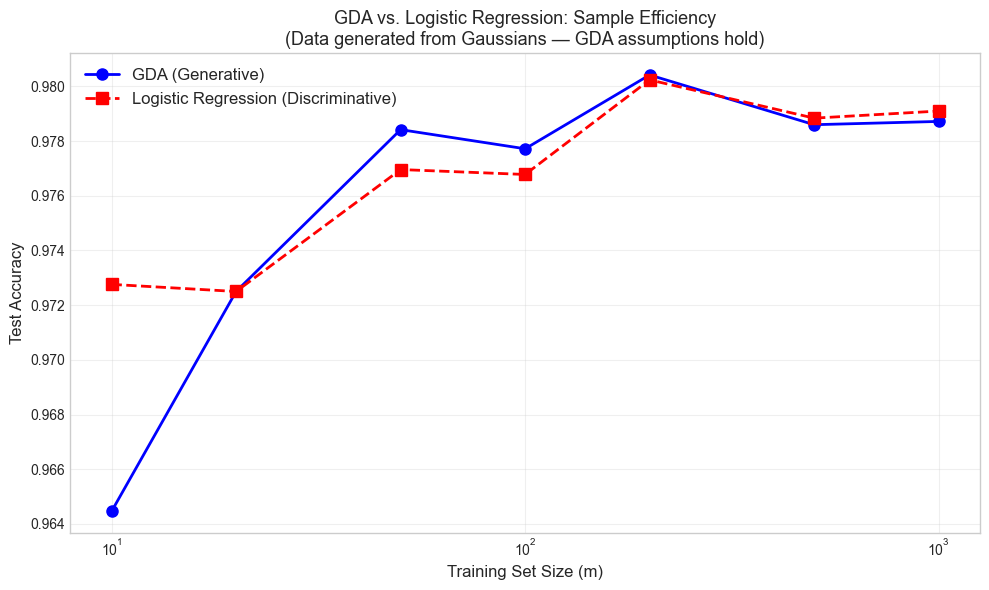

Observation: With small sample sizes, GDA tends to outperform Logistic Regression
because GDA's Gaussian assumption is correct and it uses the data more efficiently.
With more data, both converge to similar performance.


In [7]:
# Compare GDA vs Logistic Regression across different sample sizes

sample_sizes = [10, 20, 50, 100, 200, 500, 1000]
n_trials = 50  # average over multiple random trials

gda_accuracies = []
lr_accuracies = []

for m in sample_sizes:
    gda_accs = []
    lr_accs = []
    
    for trial in range(n_trials):
        # Generate data from Gaussian (so GDA assumptions hold)
        n_half = m // 2
        X0 = np.random.multivariate_normal([-2, -1], [[1.0, 0.3], [0.3, 1.0]], n_half)
        X1 = np.random.multivariate_normal([2, 1], [[1.0, 0.3], [0.3, 1.0]], n_half)
        X_train = np.vstack([X0, X1])
        y_train = np.concatenate([np.zeros(n_half), np.ones(n_half)])
        
        # Generate large test set
        X0_test = np.random.multivariate_normal([-2, -1], [[1.0, 0.3], [0.3, 1.0]], 500)
        X1_test = np.random.multivariate_normal([2, 1], [[1.0, 0.3], [0.3, 1.0]], 500)
        X_test = np.vstack([X0_test, X1_test])
        y_test = np.concatenate([np.zeros(500), np.ones(500)])
        
        # GDA
        gda_temp = GaussianDiscriminantAnalysis()
        import io, sys
        old_stdout = sys.stdout
        sys.stdout = io.StringIO()  # suppress print
        gda_temp.fit(X_train, y_train)
        sys.stdout = old_stdout
        gda_accs.append(gda_temp.accuracy(X_test, y_test))
        
        # Logistic Regression
        lr_temp = LogisticRegression(max_iter=1000)
        lr_temp.fit(X_train, y_train)
        lr_accs.append(lr_temp.predict(X_test) == y_test)
        lr_accs[-1] = np.mean(lr_accs[-1])
    
    gda_accuracies.append(np.mean(gda_accs))
    lr_accuracies.append(np.mean(lr_accs))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sample_sizes, gda_accuracies, 'bo-', linewidth=2, markersize=8, label='GDA (Generative)')
ax.plot(sample_sizes, lr_accuracies, 'rs--', linewidth=2, markersize=8, label='Logistic Regression (Discriminative)')
ax.set_xlabel('Training Set Size (m)', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('GDA vs. Logistic Regression: Sample Efficiency\n(Data generated from Gaussians — GDA assumptions hold)', fontsize=13)
ax.legend(fontsize=12)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Observation: With small sample sizes, GDA tends to outperform Logistic Regression")
print("because GDA's Gaussian assumption is correct and it uses the data more efficiently.")
print("With more data, both converge to similar performance.")

---
# Part 3: Naive Bayes

## 3.1 Motivation & Setup

- For **discrete** features (e.g., text, categorical data)
- Example: **Spam classification**
    - Vocabulary of $|V|$ words
    - Each email represented as $x \in \{0, 1\}^{|V|}$ (word present or not)
    - $y \in \{0, 1\}$: not spam (0) or spam (1)

## 3.2 The Naive Bayes Assumption

**Conditional independence:** Features are independent given the class.

$$p(x_1, x_2, \ldots, x_n \mid y) = \prod_{j=1}^{n} p(x_j \mid y)$$

This reduces parameters from $2^n$ to $2n + 1$!

## 3.3 Parameters

$$\phi_{j|y=k} = p(x_j = 1 \mid y = k) \quad \text{for each feature } j \text{ and class } k$$

$$\phi_y = p(y = 1)$$

In [8]:
class NaiveBayes:
    """
    Naive Bayes classifier for binary features.
    
    Implements the Multivariate Bernoulli event model with Laplace smoothing.
    
    Assumptions:
        - Features are binary: x_j in {0, 1}
        - Features are conditionally independent given the class
        - p(x1, x2, ..., xn | y) = product of p(xj | y)
    """
    
    def __init__(self, laplace_smoothing=1.0):
        self.laplace_smoothing = laplace_smoothing  # alpha for Laplace smoothing
        self.phi_y = None           # p(y=1)
        self.phi_j_given_y1 = None  # p(x_j=1 | y=1) for each feature j
        self.phi_j_given_y0 = None  # p(x_j=1 | y=0) for each feature j
        self.n_features = None
    
    def fit(self, X, y):
        """
        Fit Naive Bayes using MLE with Laplace smoothing.
        
        phi_y = count(y=1) / m
        phi_j|y=1 = (count(x_j=1 AND y=1) + alpha) / (count(y=1) + 2*alpha)
        phi_j|y=0 = (count(x_j=1 AND y=0) + alpha) / (count(y=0) + 2*alpha)
        """
        m, self.n_features = X.shape
        alpha = self.laplace_smoothing
        
        # Prior
        self.phi_y = np.mean(y == 1)
        
        # Class-conditional probabilities with Laplace smoothing
        count_y1 = np.sum(y == 1)
        count_y0 = np.sum(y == 0)
        
        # p(x_j = 1 | y = 1) for each feature j
        self.phi_j_given_y1 = (np.sum(X[y == 1], axis=0) + alpha) / (count_y1 + 2 * alpha)
        
        # p(x_j = 1 | y = 0) for each feature j
        self.phi_j_given_y0 = (np.sum(X[y == 0], axis=0) + alpha) / (count_y0 + 2 * alpha)
        
        print(f"Naive Bayes Trained:")
        print(f"  Prior p(y=1) = {self.phi_y:.4f}")
        print(f"  Number of features: {self.n_features}")
        print(f"  Laplace smoothing alpha: {alpha}")
        
        return self
    
    def _compute_log_likelihood(self, X, phi_j):
        """
        Compute log p(x | y) = sum_j [x_j * log(phi_j) + (1-x_j) * log(1-phi_j)]
        
        We use log probabilities to avoid numerical underflow from multiplying
        many small numbers.
        """
        log_probs = X * np.log(phi_j + 1e-300) + (1 - X) * np.log(1 - phi_j + 1e-300)
        return np.sum(log_probs, axis=1)  # sum over features for each sample
    
    def predict_proba(self, X):
        """Compute p(y=1 | x) using Bayes' rule (in log space)."""
        # log p(x | y=1) + log p(y=1)
        log_p_x_given_y1 = self._compute_log_likelihood(X, self.phi_j_given_y1)
        log_joint_y1 = log_p_x_given_y1 + np.log(self.phi_y + 1e-300)
        
        # log p(x | y=0) + log p(y=0)
        log_p_x_given_y0 = self._compute_log_likelihood(X, self.phi_j_given_y0)
        log_joint_y0 = log_p_x_given_y0 + np.log(1 - self.phi_y + 1e-300)
        
        # p(y=1|x) = exp(log_joint_y1) / (exp(log_joint_y0) + exp(log_joint_y1))
        # Use log-sum-exp trick for numerical stability
        max_log = np.maximum(log_joint_y0, log_joint_y1)
        log_sum = max_log + np.log(np.exp(log_joint_y0 - max_log) + np.exp(log_joint_y1 - max_log))
        
        log_posterior = log_joint_y1 - log_sum
        return np.exp(log_posterior)
    
    def predict(self, X):
        """Predict class labels."""
        return (self.predict_proba(X) >= 0.5).astype(int)
    
    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

print("Naive Bayes class defined!")

Naive Bayes class defined!


## 3.4 Spam Classification Example

Let's create a realistic spam classification scenario with a small vocabulary.

In [9]:
# Create a small spam classification dataset

vocabulary = [
    'buy', 'free', 'money', 'offer', 'click', 'winner', 'urgent',    # spam-like words
    'meeting', 'project', 'report', 'team', 'schedule', 'review',     # non-spam words  
    'hello', 'thanks', 'please', 'regards', 'attached', 'update',     # neutral words
    'discount', 'viagra', 'lottery', 'prince', 'pills', 'cheap'       # spam-like words
]

n_words = len(vocabulary)
print(f"Vocabulary size: {n_words} words")
print(f"Vocabulary: {vocabulary}")

np.random.seed(42)

def generate_email(is_spam, vocabulary_size):
    """Generate a binary feature vector for an email."""
    x = np.zeros(vocabulary_size)
    
    if is_spam:
        # Spam: higher probability for spam-like words (indices 0-6, 19-24)
        spam_indices = list(range(7)) + list(range(19, 25))
        normal_indices = list(range(7, 19))
        
        for idx in spam_indices:
            x[idx] = np.random.binomial(1, 0.6)  # 60% chance
        for idx in normal_indices:
            x[idx] = np.random.binomial(1, 0.1)  # 10% chance
    else:
        # Not spam: higher probability for work-related words
        spam_indices = list(range(7)) + list(range(19, 25))
        normal_indices = list(range(7, 19))
        
        for idx in spam_indices:
            x[idx] = np.random.binomial(1, 0.05)  # 5% chance
        for idx in normal_indices:
            x[idx] = np.random.binomial(1, 0.5)   # 50% chance
    
    return x

# Generate dataset
n_emails = 1000
X_emails = []
y_emails = []

for i in range(n_emails):
    is_spam = np.random.binomial(1, 0.4)  # 40% spam rate
    X_emails.append(generate_email(is_spam, n_words))
    y_emails.append(is_spam)

X_emails = np.array(X_emails)
y_emails = np.array(y_emails)

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_emails, y_emails, test_size=0.3, random_state=42
)

print(f"\nDataset: {n_emails} emails")
print(f"  Spam: {np.sum(y_emails)} ({np.mean(y_emails)*100:.1f}%)")
print(f"  Not spam: {n_emails - np.sum(y_emails)} ({(1-np.mean(y_emails))*100:.1f}%)")
print(f"  Train: {len(y_train_nb)}, Test: {len(y_test_nb)}")

Vocabulary size: 25 words
Vocabulary: ['buy', 'free', 'money', 'offer', 'click', 'winner', 'urgent', 'meeting', 'project', 'report', 'team', 'schedule', 'review', 'hello', 'thanks', 'please', 'regards', 'attached', 'update', 'discount', 'viagra', 'lottery', 'prince', 'pills', 'cheap']

Dataset: 1000 emails
  Spam: 405 (40.5%)
  Not spam: 595 (59.5%)
  Train: 700, Test: 300


In [10]:
# Train Naive Bayes
nb = NaiveBayes(laplace_smoothing=1.0)
nb.fit(X_train_nb, y_train_nb)

print(f"\nTraining accuracy: {nb.accuracy(X_train_nb, y_train_nb):.4f}")
print(f"Test accuracy:     {nb.accuracy(X_test_nb, y_test_nb):.4f}")

Naive Bayes Trained:
  Prior p(y=1) = 0.4286
  Number of features: 25
  Laplace smoothing alpha: 1.0

Training accuracy: 0.9986
Test accuracy:     1.0000


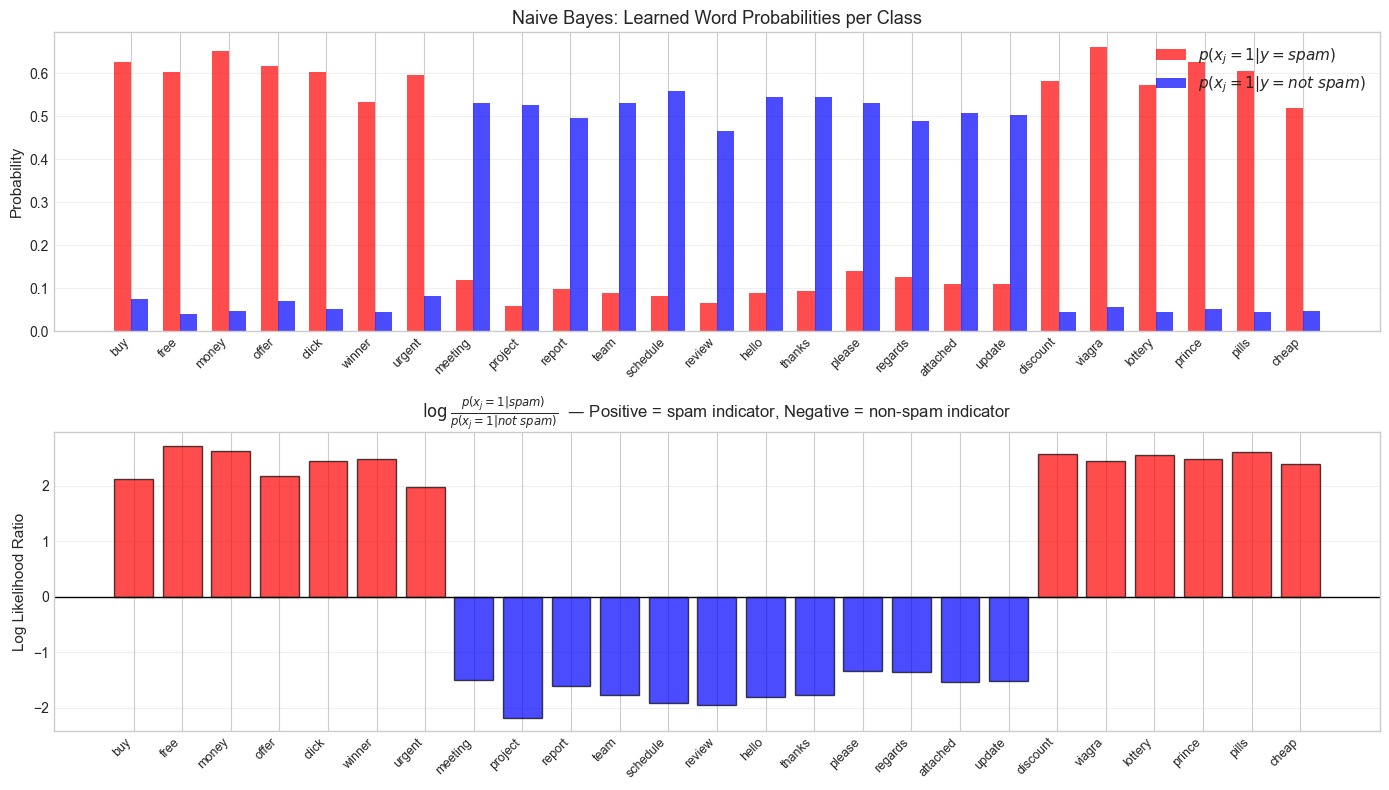

Top 5 SPAM indicators:
  'free': log ratio = 2.717
  'money': log ratio = 2.625
  'pills': log ratio = 2.605
  'discount': log ratio = 2.566
  'lottery': log ratio = 2.549

Top 5 NON-SPAM indicators:
  'team': log ratio = -1.779
  'hello': log ratio = -1.807
  'schedule': log ratio = -1.911
  'review': log ratio = -1.949
  'project': log ratio = -2.180


In [11]:
# Visualize learned parameters: which words are most indicative of spam?

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# p(word | spam) vs p(word | not spam)
x_pos = np.arange(n_words)
width = 0.35

ax = axes[0]
bars1 = ax.bar(x_pos - width/2, nb.phi_j_given_y1, width, color='red', alpha=0.7, label='$p(x_j=1 | y=spam)$')
bars2 = ax.bar(x_pos + width/2, nb.phi_j_given_y0, width, color='blue', alpha=0.7, label='$p(x_j=1 | y=not\\ spam)$')
ax.set_xticks(x_pos)
ax.set_xticklabels(vocabulary, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Probability', fontsize=11)
ax.set_title('Naive Bayes: Learned Word Probabilities per Class', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Log-likelihood ratio: log[p(word|spam) / p(word|not_spam)]
# Positive = more indicative of spam, Negative = more indicative of not spam
log_ratio = np.log(nb.phi_j_given_y1 / nb.phi_j_given_y0)

ax2 = axes[1]
colors = ['red' if lr > 0 else 'blue' for lr in log_ratio]
ax2.bar(x_pos, log_ratio, color=colors, alpha=0.7, edgecolor='k')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(vocabulary, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Log Likelihood Ratio', fontsize=11)
ax2.set_title('$\\log \\frac{p(x_j=1|spam)}{p(x_j=1|not\\ spam)}$  — Positive = spam indicator, Negative = non-spam indicator', fontsize=12)
ax2.axhline(y=0, color='black', linewidth=1)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print top spam and non-spam indicators
sorted_indices = np.argsort(log_ratio)[::-1]
print("Top 5 SPAM indicators:")
for i in sorted_indices[:5]:
    print(f"  '{vocabulary[i]}': log ratio = {log_ratio[i]:.3f}")

print("\nTop 5 NON-SPAM indicators:")
for i in sorted_indices[-5:]:
    print(f"  '{vocabulary[i]}': log ratio = {log_ratio[i]:.3f}")

## 3.5 Laplace Smoothing

### The Problem
Without smoothing, if a word **never appears** in spam during training:
- $p(x_j = 1 | y = 1) = 0$
- The **entire product** $\prod_j p(x_j | y)$ becomes 0
- One unseen word **kills** the prediction!

### The Solution
Add pseudo-counts (Laplace smoothing):

$$\phi_{j|y=k} = \frac{\text{count}(x_j = 1 \wedge y = k) + \alpha}{\text{count}(y = k) + 2\alpha}$$

- $\alpha = 1$ is standard (add-one smoothing)
- Ensures no probability is ever exactly 0 or 1
- With $k$ possible values for a feature, add $k \cdot \alpha$ to the denominator

### Let's demonstrate the effect:

SMALL DATASET — Demonstrating Laplace Smoothing

--- Without Smoothing (alpha ≈ 0) ---
Naive Bayes Trained:
  Prior p(y=1) = 0.5000
  Number of features: 5
  Laplace smoothing alpha: 1e-10

p(x_j=1 | spam):     [1.00000000e+00 6.66666667e-01 6.66666667e-01 3.33333333e-11
 3.33333333e-11]
p(x_j=1 | not spam): [3.33333333e-11 3.33333333e-11 3.33333333e-11 6.66666667e-01
 6.66666667e-01]
⚠️  Notice the 0.000 values — these will cause problems!

--- With Laplace Smoothing (alpha = 1) ---
Naive Bayes Trained:
  Prior p(y=1) = 0.5000
  Number of features: 5
  Laplace smoothing alpha: 1.0

p(x_j=1 | spam):     [0.8 0.6 0.6 0.2 0.2]
p(x_j=1 | not spam): [0.2 0.2 0.2 0.6 0.6]
✓  No zero probabilities!

--- Testing on an email with 'meeting' (never seen in spam) ---
Without smoothing — p(spam|x) = 0.000000
With smoothing    — p(spam|x) = 0.040000


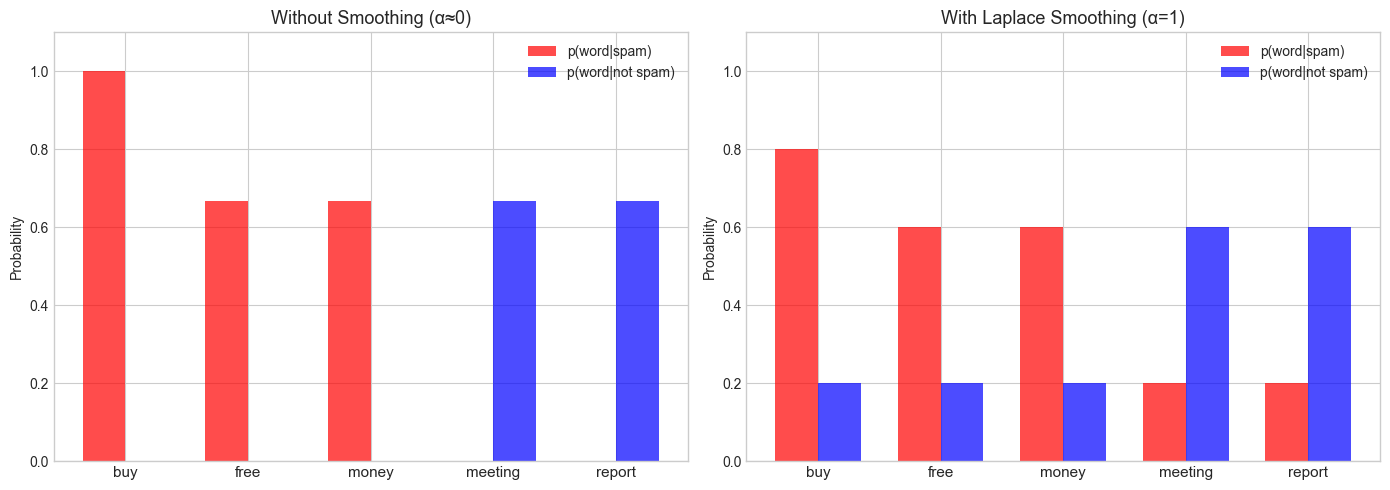

In [12]:
# Demonstrate Laplace smoothing effect

# Create a scenario where some words never appear in one class
X_small = np.array([
    [1, 1, 0, 0, 0],  # spam
    [1, 0, 1, 0, 0],  # spam
    [1, 1, 1, 0, 0],  # spam
    [0, 0, 0, 1, 1],  # not spam
    [0, 0, 0, 1, 0],  # not spam
    [0, 0, 0, 0, 1],  # not spam
])
y_small = np.array([1, 1, 1, 0, 0, 0])
small_vocab = ['buy', 'free', 'money', 'meeting', 'report']

print("=" * 60)
print("SMALL DATASET — Demonstrating Laplace Smoothing")
print("=" * 60)

# Without smoothing (alpha ≈ 0)
print("\n--- Without Smoothing (alpha ≈ 0) ---")
nb_no_smooth = NaiveBayes(laplace_smoothing=1e-10)
nb_no_smooth.fit(X_small, y_small)
print(f"\np(x_j=1 | spam):     {nb_no_smooth.phi_j_given_y1}")
print(f"p(x_j=1 | not spam): {nb_no_smooth.phi_j_given_y0}")
print("⚠️  Notice the 0.000 values — these will cause problems!")

# With smoothing (alpha = 1)
print("\n--- With Laplace Smoothing (alpha = 1) ---")
nb_smooth = NaiveBayes(laplace_smoothing=1.0)
nb_smooth.fit(X_small, y_small)
print(f"\np(x_j=1 | spam):     {nb_smooth.phi_j_given_y1}")
print(f"p(x_j=1 | not spam): {nb_smooth.phi_j_given_y0}")
print("✓  No zero probabilities!")

# Test with an email that has a word unseen in one class
print("\n--- Testing on an email with 'meeting' (never seen in spam) ---")
test_email = np.array([[0, 0, 0, 1, 0]])  # contains only 'meeting'

pred_no_smooth = nb_no_smooth.predict_proba(test_email)
pred_smooth = nb_smooth.predict_proba(test_email)

print(f"Without smoothing — p(spam|x) = {pred_no_smooth[0]:.6f}")
print(f"With smoothing    — p(spam|x) = {pred_smooth[0]:.6f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos = np.arange(len(small_vocab))
width = 0.35

for ax, model, title in [(axes[0], nb_no_smooth, 'Without Smoothing (α≈0)'),
                           (axes[1], nb_smooth, 'With Laplace Smoothing (α=1)')]:
    ax.bar(x_pos - width/2, model.phi_j_given_y1, width, color='red', alpha=0.7, label='p(word|spam)')
    ax.bar(x_pos + width/2, model.phi_j_given_y0, width, color='blue', alpha=0.7, label='p(word|not spam)')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(small_vocab, fontsize=11)
    ax.set_ylabel('Probability')
    ax.set_title(title, fontsize=13)
    ax.legend()
    ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

## 3.6 Classifying New Emails

Let's see Naive Bayes in action on individual emails!

In [13]:
# Classify some example emails

def classify_email(model, feature_vector, vocabulary, true_label=None):
    """Classify an email and show the reasoning."""
    prob_spam = model.predict_proba(feature_vector.reshape(1, -1))[0]
    prediction = "SPAM" if prob_spam >= 0.5 else "NOT SPAM"
    
    # Show which words are present
    present_words = [vocabulary[j] for j in range(len(vocabulary)) if feature_vector[j] == 1]
    
    print(f"  Words present: {present_words}")
    print(f"  p(spam|email) = {prob_spam:.4f}")
    print(f"  Prediction: {prediction}", end="")
    if true_label is not None:
        true_str = "SPAM" if true_label == 1 else "NOT SPAM"
        correct = "✓" if prediction == true_str else "✗"
        print(f"  (True: {true_str}) {correct}")
    else:
        print()
    print()

# Create test emails
print("=" * 60)
print("CLASSIFYING INDIVIDUAL EMAILS")
print("=" * 60)

# Email 1: Clearly spam
email1 = np.zeros(n_words)
spam_words = ['buy', 'free', 'money', 'discount', 'click', 'winner']
for word in spam_words:
    if word in vocabulary:
        email1[vocabulary.index(word)] = 1
print("\nEmail 1 (should be spam):")
classify_email(nb, email1, vocabulary)

# Email 2: Clearly not spam
email2 = np.zeros(n_words)
work_words = ['meeting', 'project', 'report', 'team', 'schedule']
for word in work_words:
    if word in vocabulary:
        email2[vocabulary.index(word)] = 1
print("Email 2 (should be not spam):")
classify_email(nb, email2, vocabulary)

# Email 3: Ambiguous
email3 = np.zeros(n_words)
mixed_words = ['free', 'update', 'offer', 'please', 'review']
for word in mixed_words:
    if word in vocabulary:
        email3[vocabulary.index(word)] = 1
print("Email 3 (ambiguous):")
classify_email(nb, email3, vocabulary)

# Email 4: Empty email
email4 = np.zeros(n_words)
print("Email 4 (empty — no words):")
classify_email(nb, email4, vocabulary)

CLASSIFYING INDIVIDUAL EMAILS

Email 1 (should be spam):
  Words present: ['buy', 'free', 'money', 'click', 'winner', 'discount']
  p(spam|email) = 1.0000
  Prediction: SPAM

Email 2 (should be not spam):
  Words present: ['meeting', 'project', 'report', 'team', 'schedule']
  p(spam|email) = 0.0000
  Prediction: NOT SPAM

Email 3 (ambiguous):
  Words present: ['free', 'offer', 'review', 'please', 'update']
  p(spam|email) = 0.0203
  Prediction: NOT SPAM

Email 4 (empty — no words):
  Words present: []
  p(spam|email) = 0.0182
  Prediction: NOT SPAM



## 3.7 Multinomial Event Model vs. Multivariate Bernoulli

The lecture mentions two event models for text:

| | Multivariate Bernoulli | Multinomial |
|---|---|---|
| **Representation** | $x \in \{0,1\}^{|V|}$ — binary vector | $x_j$ = identity of $j$-th word |
| **Models** | Presence/absence of words | Actual word frequencies |
| **Better for** | Short documents | Longer documents |
| **Note** | What we implemented above | Accounts for word counts |

The Multinomial model generally performs better for text classification because it captures how many times each word appears, not just whether it appears.

---
# Part 4: GDA vs. Logistic Regression — When Assumptions Break

Let's compare GDA and Logistic Regression when the data is **NOT** Gaussian.

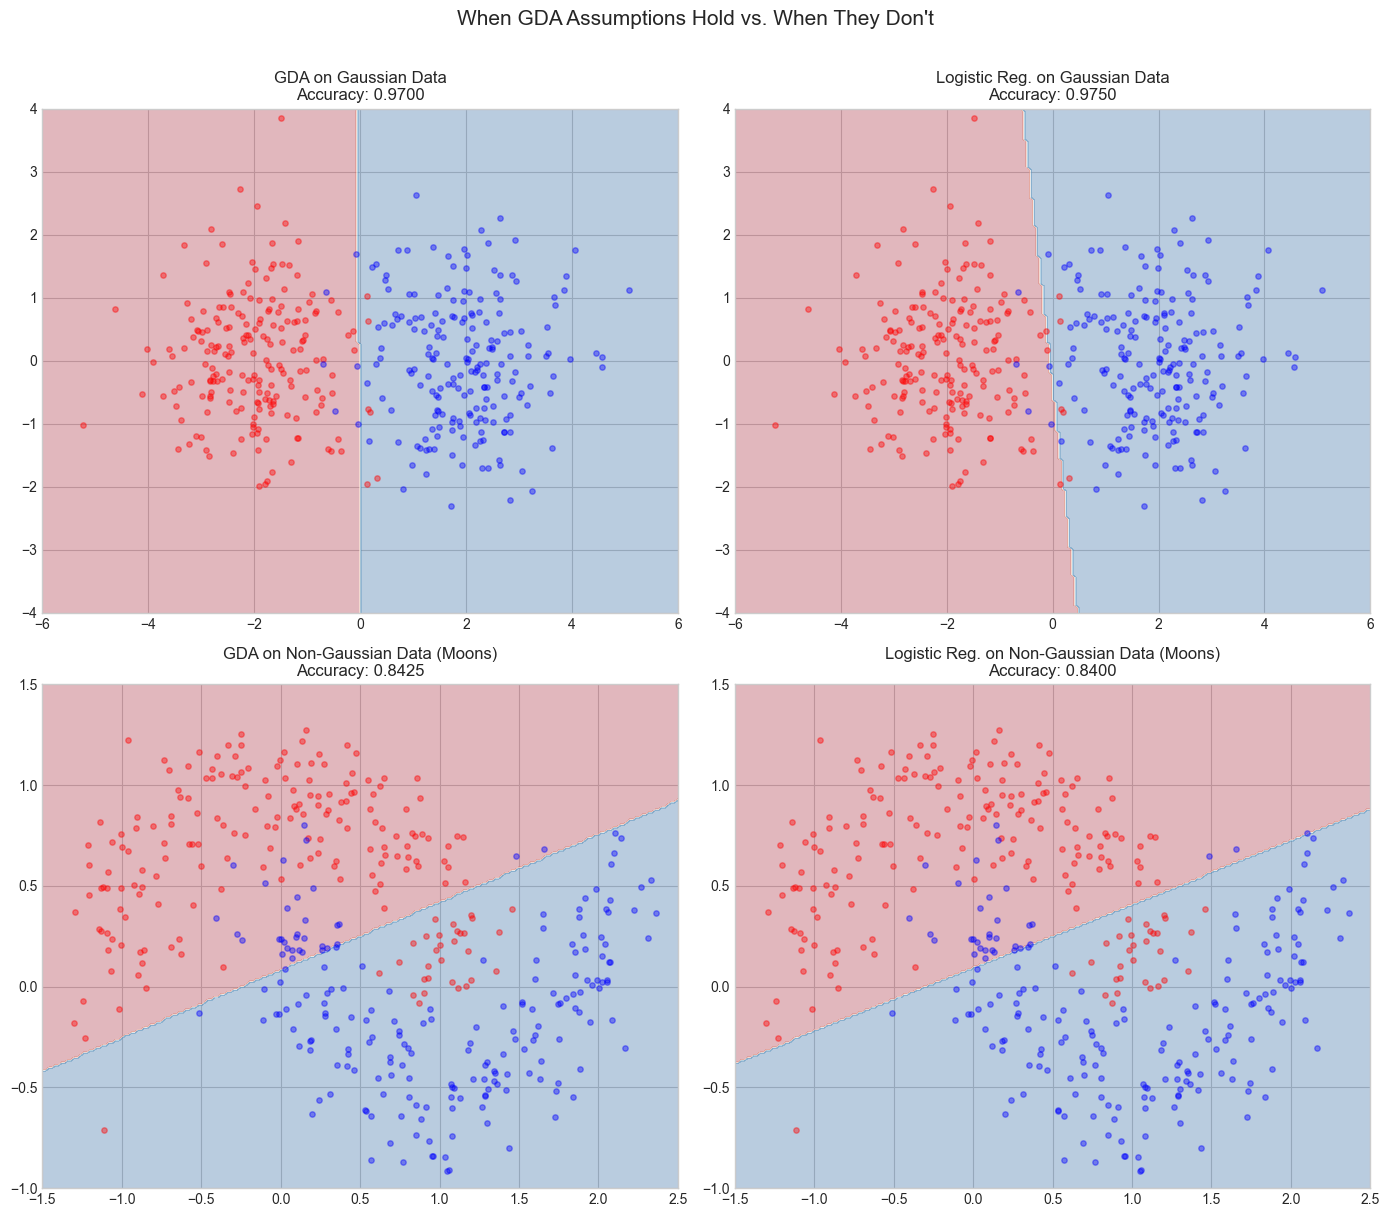

Row 1: Gaussian data — Both work well (GDA assumptions are met)
Row 2: Moon-shaped data — Both struggle because neither model captures the nonlinearity
Key point: GDA's linear boundary works great when data IS Gaussian,
but no linear model works well on moons (need nonlinear models like neural nets/SVM)


In [14]:
# Scenario 1: Data IS Gaussian → GDA assumptions hold
np.random.seed(42)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# --- Gaussian Data (GDA assumptions hold) ---
X0_gauss = np.random.multivariate_normal([-2, 0], [[1, 0], [0, 1]], 200)
X1_gauss = np.random.multivariate_normal([2, 0], [[1, 0], [0, 1]], 200)
X_gauss = np.vstack([X0_gauss, X1_gauss])
y_gauss = np.concatenate([np.zeros(200), np.ones(200)])

# Train GDA
import io, sys
old_stdout = sys.stdout
sys.stdout = io.StringIO()
gda_gauss = GaussianDiscriminantAnalysis()
gda_gauss.fit(X_gauss, y_gauss)
sys.stdout = old_stdout

# Train Logistic Regression
lr_gauss = LogisticRegression(max_iter=1000)
lr_gauss.fit(X_gauss, y_gauss)

# Plot GDA
ax = axes[0][0]
xx, yy = np.meshgrid(np.linspace(-6, 6, 200), np.linspace(-4, 4, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z_gda = gda_gauss.predict(grid).reshape(xx.shape)
ax.contourf(xx, yy, Z_gda, alpha=0.3, cmap='RdBu')
ax.scatter(X_gauss[y_gauss==0, 0], X_gauss[y_gauss==0, 1], c='red', alpha=0.4, s=15)
ax.scatter(X_gauss[y_gauss==1, 0], X_gauss[y_gauss==1, 1], c='blue', alpha=0.4, s=15)
gda_acc = gda_gauss.accuracy(X_gauss, y_gauss)
ax.set_title(f'GDA on Gaussian Data\nAccuracy: {gda_acc:.4f}', fontsize=12)

# Plot LR
ax = axes[0][1]
Z_lr = lr_gauss.predict(grid).reshape(xx.shape)
ax.contourf(xx, yy, Z_lr, alpha=0.3, cmap='RdBu')
ax.scatter(X_gauss[y_gauss==0, 0], X_gauss[y_gauss==0, 1], c='red', alpha=0.4, s=15)
ax.scatter(X_gauss[y_gauss==1, 0], X_gauss[y_gauss==1, 1], c='blue', alpha=0.4, s=15)
lr_acc = lr_gauss.score(X_gauss, y_gauss)
ax.set_title(f'Logistic Reg. on Gaussian Data\nAccuracy: {lr_acc:.4f}', fontsize=12)

# --- Non-Gaussian Data (GDA assumptions violated) ---
# Create banana/moon-shaped data
from sklearn.datasets import make_moons
X_moons, y_moons = make_moons(n_samples=400, noise=0.2, random_state=42)

old_stdout = sys.stdout
sys.stdout = io.StringIO()
gda_moons = GaussianDiscriminantAnalysis()
gda_moons.fit(X_moons, y_moons)
sys.stdout = old_stdout

lr_moons = LogisticRegression(max_iter=1000)
lr_moons.fit(X_moons, y_moons)

# Plot GDA
ax = axes[1][0]
xx2, yy2 = np.meshgrid(np.linspace(-1.5, 2.5, 200), np.linspace(-1, 1.5, 200))
grid2 = np.c_[xx2.ravel(), yy2.ravel()]
Z_gda2 = gda_moons.predict(grid2).reshape(xx2.shape)
ax.contourf(xx2, yy2, Z_gda2, alpha=0.3, cmap='RdBu')
ax.scatter(X_moons[y_moons==0, 0], X_moons[y_moons==0, 1], c='red', alpha=0.4, s=15)
ax.scatter(X_moons[y_moons==1, 0], X_moons[y_moons==1, 1], c='blue', alpha=0.4, s=15)
gda_acc2 = gda_moons.accuracy(X_moons, y_moons)
ax.set_title(f'GDA on Non-Gaussian Data (Moons)\nAccuracy: {gda_acc2:.4f}', fontsize=12)

# Plot LR
ax = axes[1][1]
Z_lr2 = lr_moons.predict(grid2).reshape(xx2.shape)
ax.contourf(xx2, yy2, Z_lr2, alpha=0.3, cmap='RdBu')
ax.scatter(X_moons[y_moons==0, 0], X_moons[y_moons==0, 1], c='red', alpha=0.4, s=15)
ax.scatter(X_moons[y_moons==1, 0], X_moons[y_moons==1, 1], c='blue', alpha=0.4, s=15)
lr_acc2 = lr_moons.score(X_moons, y_moons)
ax.set_title(f'Logistic Reg. on Non-Gaussian Data (Moons)\nAccuracy: {lr_acc2:.4f}', fontsize=12)

plt.suptitle('When GDA Assumptions Hold vs. When They Don\'t', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print("Row 1: Gaussian data — Both work well (GDA assumptions are met)")
print("Row 2: Moon-shaped data — Both struggle because neither model captures the nonlinearity")
print("Key point: GDA's linear boundary works great when data IS Gaussian,")
print("but no linear model works well on moons (need nonlinear models like neural nets/SVM)")

---
# Part 5: Putting It All Together

## 5.1 Complete Classification Pipeline Comparison

Let's compare **GDA**, **Logistic Regression**, and **Naive Bayes** on a single dataset.

MODEL COMPARISON ON THE SAME DATASET

Model                             Train Acc     Test Acc
------------------------------------------------------
GDA (Generative)                     0.9457       0.9067
Logistic Reg (Discriminative)        0.9486       0.9133
Naive Bayes (Generative)             0.9514       0.9267


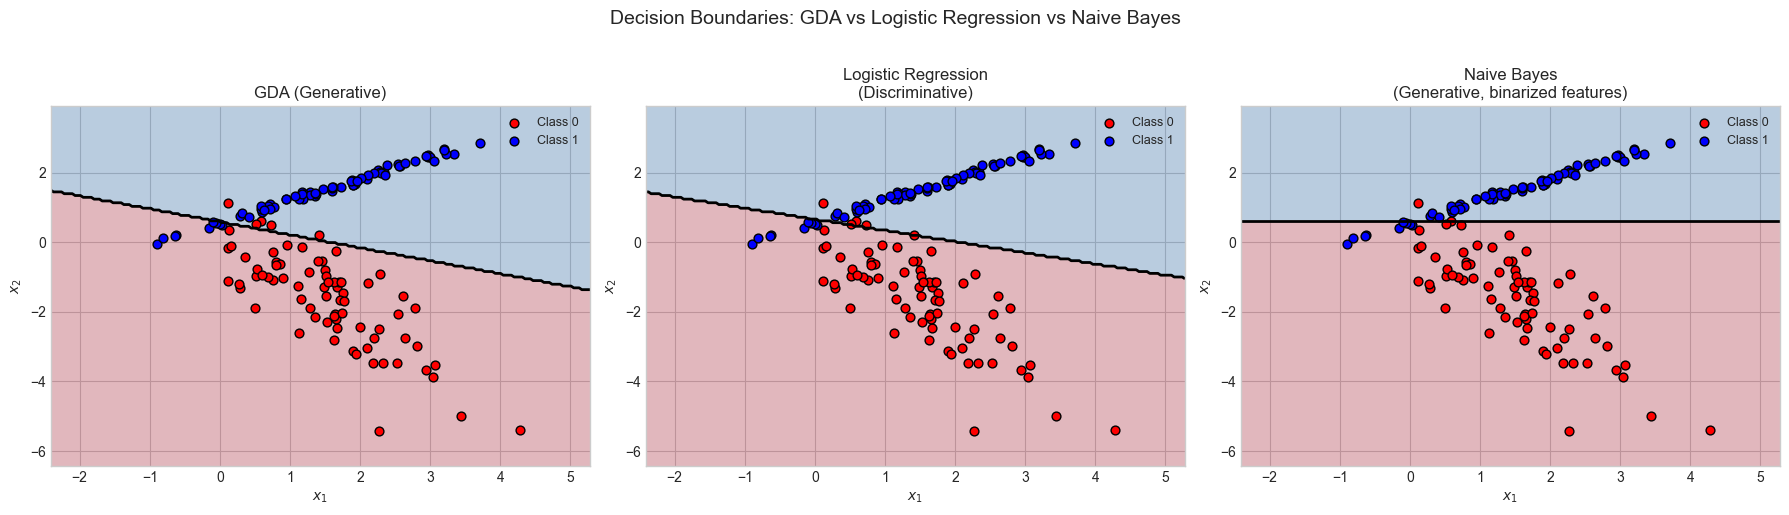

In [15]:
# Generate a dataset with mixed feature types
# We'll use a continuous dataset for GDA & LR, and binarize it for NB

np.random.seed(42)
X_compare, y_compare = make_classification(
    n_samples=500, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.5, random_state=42
)

X_tr, X_te, y_tr, y_te = train_test_split(X_compare, y_compare, test_size=0.3, random_state=42)

# Binarize for Naive Bayes (threshold at median)
X_tr_binary = (X_tr > np.median(X_tr, axis=0)).astype(int)
X_te_binary = (X_te > np.median(X_tr, axis=0)).astype(int)

# --- Train all three ---
# 1. GDA
old_stdout = sys.stdout
sys.stdout = io.StringIO()
gda_comp = GaussianDiscriminantAnalysis()
gda_comp.fit(X_tr, y_tr)
sys.stdout = old_stdout

# 2. Logistic Regression
lr_comp = LogisticRegression(max_iter=1000)
lr_comp.fit(X_tr, y_tr)

# 3. Naive Bayes
sys.stdout = io.StringIO()
nb_comp = NaiveBayes(laplace_smoothing=1.0)
nb_comp.fit(X_tr_binary, y_tr)
sys.stdout = old_stdout

# --- Evaluate ---
print("=" * 50)
print("MODEL COMPARISON ON THE SAME DATASET")
print("=" * 50)
print(f"\n{'Model':<30} {'Train Acc':>12} {'Test Acc':>12}")
print("-" * 54)

models_results = [
    ("GDA (Generative)", gda_comp.accuracy(X_tr, y_tr), gda_comp.accuracy(X_te, y_te)),
    ("Logistic Reg (Discriminative)", lr_comp.score(X_tr, y_tr), lr_comp.score(X_te, y_te)),
    ("Naive Bayes (Generative)", nb_comp.accuracy(X_tr_binary, y_tr), nb_comp.accuracy(X_te_binary, y_te)),
]

for name, train_acc, test_acc in models_results:
    print(f"{name:<30} {train_acc:>12.4f} {test_acc:>12.4f}")

# Visualize decision boundaries
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['GDA (Generative)', 'Logistic Regression\n(Discriminative)', 'Naive Bayes\n(Generative, binarized features)']

xx, yy = np.meshgrid(np.linspace(X_compare[:, 0].min()-1, X_compare[:, 0].max()+1, 200),
                     np.linspace(X_compare[:, 1].min()-1, X_compare[:, 1].max()+1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_binary = (grid > np.median(X_tr, axis=0)).astype(int)

predictions = [
    gda_comp.predict(grid),
    lr_comp.predict(grid),
    nb_comp.predict(grid_binary)
]

for ax, Z_pred, title in zip(axes, predictions, titles):
    Z = Z_pred.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    ax.scatter(X_te[y_te==0, 0], X_te[y_te==0, 1], c='red', edgecolors='k', s=40, label='Class 0')
    ax.scatter(X_te[y_te==1, 0], X_te[y_te==1, 1], c='blue', edgecolors='k', s=40, label='Class 1')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.legend(fontsize=9)

plt.suptitle('Decision Boundaries: GDA vs Logistic Regression vs Naive Bayes', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
# Part 6: Exercises

## Exercise 1: Quadratic Discriminant Analysis (QDA)

In GDA, we assumed **shared** covariance $\Sigma$ for both classes. What if each class has its **own** covariance matrix $\Sigma_0$ and $\Sigma_1$?

This gives **Quadratic Discriminant Analysis (QDA)** — the decision boundary becomes a quadratic (curved) surface.

**Task:** Modify the GDA class to implement QDA by:
1. Computing separate covariance matrices $\Sigma_0$ and $\Sigma_1$
2. Using the appropriate $\Sigma_k$ when computing $p(x | y = k)$

In [16]:
# Exercise 1: Implement QDA

# TODO: Modify GaussianDiscriminantAnalysis to create QDA
# Hints:
#   - In fit(): compute self.Sigma_0 and self.Sigma_1 separately
#   - In _multivariate_gaussian(): accept Sigma as a parameter
#   - In predict_proba(): use Sigma_0 for class 0 and Sigma_1 for class 1

# class QuadraticDiscriminantAnalysis:
#     def __init__(self):
#         self.phi = None
#         self.mu_0 = None
#         self.mu_1 = None
#         self.Sigma_0 = None  # separate covariance for class 0
#         self.Sigma_1 = None  # separate covariance for class 1
#     
#     def fit(self, X, y):
#         m, n = X.shape
#         self.phi = np.mean(y == 1)
#         self.mu_0 = np.mean(X[y == 0], axis=0)
#         self.mu_1 = np.mean(X[y == 1], axis=0)
#         
#         X0_centered = X[y == 0] - self.mu_0
#         X1_centered = X[y == 1] - self.mu_1
#         self.Sigma_0 = (X0_centered.T @ X0_centered) / np.sum(y == 0)
#         self.Sigma_1 = (X1_centered.T @ X1_centered) / np.sum(y == 1)
#         return self
#     
#     # TODO: Complete the rest (predict_proba, predict, etc.)

print("Exercise 1: Implement QDA — uncomment and complete the code above!")
print("Test it on the moons dataset to see if the curved boundary helps.")

Exercise 1: Implement QDA — uncomment and complete the code above!
Test it on the moons dataset to see if the curved boundary helps.


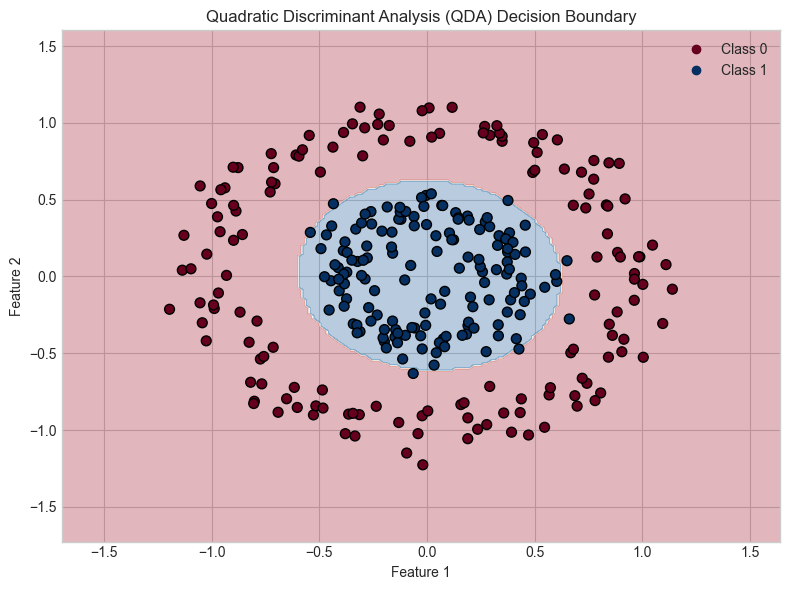

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

# ==========================================
# 1. Define the QDA Class
# ==========================================
class QuadraticDiscriminantAnalysis:
    def __init__(self):
        self.phi = None
        self.mu_0 = None
        self.mu_1 = None
        self.Sigma_0 = None
        self.Sigma_1 = None
    
    def fit(self, X, y):
        self.phi = np.mean(y == 1)
        self.mu_0 = np.mean(X[y == 0], axis=0)
        self.mu_1 = np.mean(X[y == 1], axis=0)
        
        X0_centered = X[y == 0] - self.mu_0
        X1_centered = X[y == 1] - self.mu_1
        
        self.Sigma_0 = (X0_centered.T @ X0_centered) / np.sum(y == 0)
        self.Sigma_1 = (X1_centered.T @ X1_centered) / np.sum(y == 1)
        return self

    def _multivariate_gaussian(self, X, mu, Sigma):
        n = X.shape[1]
        # Add a tiny value to the diagonal to ensure invertibility
        Sigma_reg = Sigma + np.eye(n) * 1e-6 
        
        det_Sigma = np.linalg.det(Sigma_reg)
        inv_Sigma = np.linalg.inv(Sigma_reg)
        
        diff = X - mu
        exponent = -0.5 * np.sum((diff @ inv_Sigma) * diff, axis=1)
        normalization = 1.0 / (((2 * np.pi) ** (n / 2)) * np.sqrt(det_Sigma))
        return normalization * np.exp(exponent)

    def predict_proba(self, X):
        p_x_given_y0 = self._multivariate_gaussian(X, self.mu_0, self.Sigma_0)
        p_x_given_y1 = self._multivariate_gaussian(X, self.mu_1, self.Sigma_1)
        
        p_y0 = 1 - self.phi
        p_y1 = self.phi
        
        numerator = p_x_given_y1 * p_y1
        denominator = (p_x_given_y0 * p_y0) + numerator
        return numerator / denominator
        
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# ==========================================
# 2. Generate Data & Train Model
# ==========================================
# Create a dataset where one class surrounds another
# This guarantees very different covariance matrices for the two classes
X, y = make_circles(n_samples=300, noise=0.1, factor=0.4, random_state=42)

# Initialize and fit the QDA model
qda = QuadraticDiscriminantAnalysis()
qda.fit(X, y)

# ==========================================
# 3. Plot the Decision Boundary
# ==========================================
def plot_decision_boundary(model, X, y):
    # Determine grid bounds
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    # Generate a grid of points
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Predict probabilities for the entire grid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid_points).reshape(xx.shape)
    
    # Plotting
    plt.figure(figsize=(8, 6))
    
    # Draw the boundary contours
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
    
    # Scatter the original data points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdBu, s=50)
    
    plt.title("Quadratic Discriminant Analysis (QDA) Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    
    # Add a legend
    handles, _ = scatter.legend_elements()
    plt.legend(handles, ["Class 0", "Class 1"], loc="best")
    
    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_decision_boundary(qda, X, y)

## Exercise 2: Effect of Laplace Smoothing Parameter

Try different values of the Laplace smoothing parameter $\alpha$ and observe the effect on Naive Bayes performance.

In [18]:
# Exercise 2: Vary Laplace smoothing and observe effect

# TODO: Complete the code below

# alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
# train_accs = []
# test_accs = []
#
# for alpha in alphas:
#     import io, sys
#     old_stdout = sys.stdout
#     sys.stdout = io.StringIO()
#     nb_temp = NaiveBayes(laplace_smoothing=alpha)
#     nb_temp.fit(X_train_nb, y_train_nb)
#     sys.stdout = old_stdout
#     
#     train_accs.append(nb_temp.accuracy(X_train_nb, y_train_nb))
#     test_accs.append(nb_temp.accuracy(X_test_nb, y_test_nb))
#
# plt.figure(figsize=(10, 5))
# plt.plot(alphas, train_accs, 'bo-', label='Train')
# plt.plot(alphas, test_accs, 'rs--', label='Test')
# plt.xscale('log')
# plt.xlabel('Laplace Smoothing α')
# plt.ylabel('Accuracy')
# plt.title('Effect of Laplace Smoothing on Naive Bayes')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

print("Exercise 2: Uncomment the code above and observe the effect!")
print("Question: What happens with very small α? Very large α?")

Exercise 2: Uncomment the code above and observe the effect!
Question: What happens with very small α? Very large α?


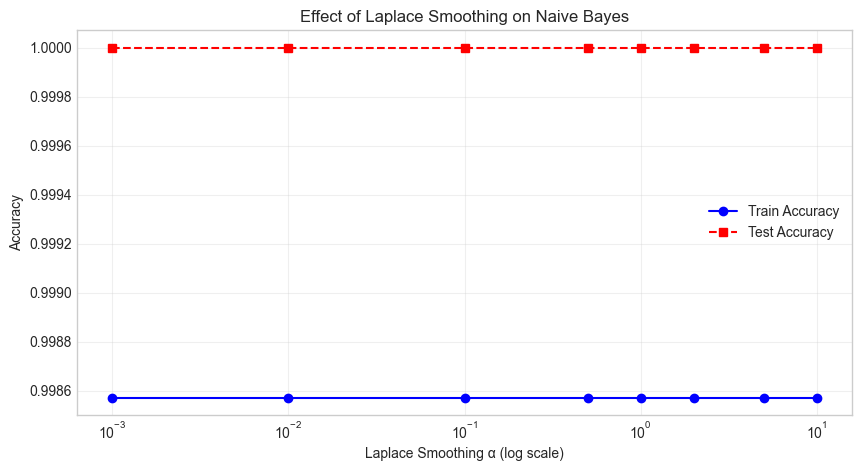

In [19]:
import matplotlib.pyplot as plt
import sys
import io

alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
train_accs = []
test_accs = []

for alpha in alphas:
    # Temporarily suppress print statements from the fit method
    old_stdout = sys.stdout
    sys.stdout = io.StringIO()
    
    # Initialize and fit the Naive Bayes model with the current alpha
    nb_temp = NaiveBayes(laplace_smoothing=alpha)
    nb_temp.fit(X_train_nb, y_train_nb)
    
    # Restore normal printing
    sys.stdout = old_stdout
    
    # Calculate and store accuracies
    train_accs.append(nb_temp.accuracy(X_train_nb, y_train_nb))
    test_accs.append(nb_temp.accuracy(X_test_nb, y_test_nb))

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(alphas, train_accs, 'bo-', label='Train Accuracy')
plt.plot(alphas, test_accs, 'rs--', label='Test Accuracy')
plt.xscale('log')
plt.xlabel('Laplace Smoothing α (log scale)')
plt.ylabel('Accuracy')
plt.title('Effect of Laplace Smoothing on Naive Bayes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Exercise 3: Naive Bayes with Multinomial Event Model

Implement the **Multinomial** Naive Bayes where features represent word **counts** instead of binary presence/absence.

$$p(x_j = w | y) = \frac{\text{count of word } w \text{ in class } y \text{ documents} + \alpha}{\text{total words in class } y \text{ documents} + \alpha \cdot |V|}$$

In [20]:
# Exercise 3: Multinomial Naive Bayes

# TODO: Implement MultinomialNaiveBayes

# class MultinomialNaiveBayes:
#     """
#     Multinomial Naive Bayes for word count features.
#     
#     Instead of binary features, x_j represents the COUNT of word j.
#     """
#     def __init__(self, laplace_smoothing=1.0):
#         self.alpha = laplace_smoothing
#         self.log_phi_j_given_y = {}  # log p(word j | class y)
#         self.log_prior = {}
#     
#     def fit(self, X, y):
#         classes = np.unique(y)
#         for c in classes:
#             X_c = X[y == c]
#             # Total word count per word across all documents in class c
#             word_counts = np.sum(X_c, axis=0) + self.alpha
#             total_words = np.sum(word_counts)
#             self.log_phi_j_given_y[c] = np.log(word_counts / total_words)
#             self.log_prior[c] = np.log(np.mean(y == c))
#         return self
#     
#     def predict(self, X):
#         # TODO: implement prediction
#         pass

print("Exercise 3: Implement Multinomial Naive Bayes!")
print("This is more suitable for text classification with word counts.")

Exercise 3: Implement Multinomial Naive Bayes!
This is more suitable for text classification with word counts.


In [22]:
import numpy as np

class MultinomialNaiveBayes:
    """
    Multinomial Naive Bayes for word count features.
    
    Instead of binary features, x_j represents the COUNT of word j.
    """
    def __init__(self, laplace_smoothing=1.0):
        self.alpha = laplace_smoothing
        self.log_phi_j_given_y = {}  # log p(word j | class c)
        self.log_prior = {}          # log p(y = c)
    
    def fit(self, X, y):
        self.classes = np.unique(y)
        for c in self.classes:
            X_c = X[y == c]
            # Total word count per word across all documents in class c
            word_counts = np.sum(X_c, axis=0) + self.alpha
            total_words = np.sum(word_counts)
            
            # Store the log probabilities
            self.log_phi_j_given_y[c] = np.log(word_counts / total_words)
            self.log_prior[c] = np.log(np.mean(y == c))
        return self
    
    def predict(self, X):
        m = X.shape[0]
        num_classes = len(self.classes)
        log_probs = np.zeros((m, num_classes))
        
        for idx, c in enumerate(self.classes):
            # The magic happens here: 
            # X is shape (m, n) containing word counts.
            # log_phi_j_given_y[c] is shape (n,) containing log probs for class c.
            # Their dot product gives us the sum of log probs weighted by word counts for each document!
            log_probs[:, idx] = X @ self.log_phi_j_given_y[c] + self.log_prior[c]
            
        # Find the index of the class with the highest log-probability for each document
        best_class_indices = np.argmax(log_probs, axis=1)
        
        # Map those indices back to the actual class labels
        return np.array([self.classes[i] for i in best_class_indices])

# ==========================================
# Quick Test to Verify it Works
# ==========================================
# Let's say we have a vocabulary of 5 words: [offer, free, money, course, machine]
# X represents the counts of these words in 4 different emails.

X_train = np.array([
    [2, 1, 2, 0, 0],  # Spam (lots of "offer", "free", "money")
    [1, 2, 1, 0, 0],  # Spam
    [0, 0, 0, 2, 1],  # Ham (lots of "course", "machine")
    [0, 0, 1, 1, 2]   # Ham
])
y_train = np.array([1, 1, 0, 0])  # 1 = Spam, 0 = Ham

# Two new emails to predict
X_test = np.array([
    [3, 0, 2, 0, 0],  # Looks like spam
    [0, 0, 0, 1, 3]   # Looks like ham
])

model = MultinomialNaiveBayes(laplace_smoothing=1.0)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print("Test Set Word Counts:\n", X_test)
print("\nPredicted Classes (1=Spam, 0=Ham):", predictions)

Test Set Word Counts:
 [[3 0 2 0 0]
 [0 0 0 1 3]]

Predicted Classes (1=Spam, 0=Ham): [1 0]


## Exercise 4: GDA on Iris Dataset

Apply GDA to the classic Iris dataset (using only 2 features for visualization). Since Iris has 3 classes, you'll need to extend GDA to multi-class (one-vs-rest or compute posteriors for all classes).

In [21]:
# Exercise 4: GDA on Iris

iris = load_iris()
X_iris = iris.data[:, :2]  # sepal length and width only
y_iris = iris.target

print(f"Iris dataset: {X_iris.shape[0]} samples, {X_iris.shape[1]} features")
print(f"Classes: {iris.target_names}")
print(f"Class distribution: {np.bincount(y_iris)}")

# TODO: For simplicity, try binary classification first (class 0 vs class 1)
# mask = y_iris != 2  # exclude class 2
# X_iris_binary = X_iris[mask]
# y_iris_binary = y_iris[mask]

# gda_iris = GaussianDiscriminantAnalysis()
# gda_iris.fit(X_iris_binary, y_iris_binary)
# print(f"Accuracy: {gda_iris.accuracy(X_iris_binary, y_iris_binary):.4f}")

# Challenge: Extend to 3 classes by implementing multi-class GDA!

print("\nExercise 4: Apply GDA to Iris!")
print("Start with binary (2 classes), then try extending to 3 classes.")

Iris dataset: 150 samples, 2 features
Classes: ['setosa' 'versicolor' 'virginica']
Class distribution: [50 50 50]

Exercise 4: Apply GDA to Iris!
Start with binary (2 classes), then try extending to 3 classes.


Iris dataset: 150 samples, 2 features
Classes: ['setosa' 'versicolor' 'virginica']
Class distribution: [50 50 50]

Binary GDA Accuracy: 0.9900
Multi-class GDA Accuracy: 0.8000


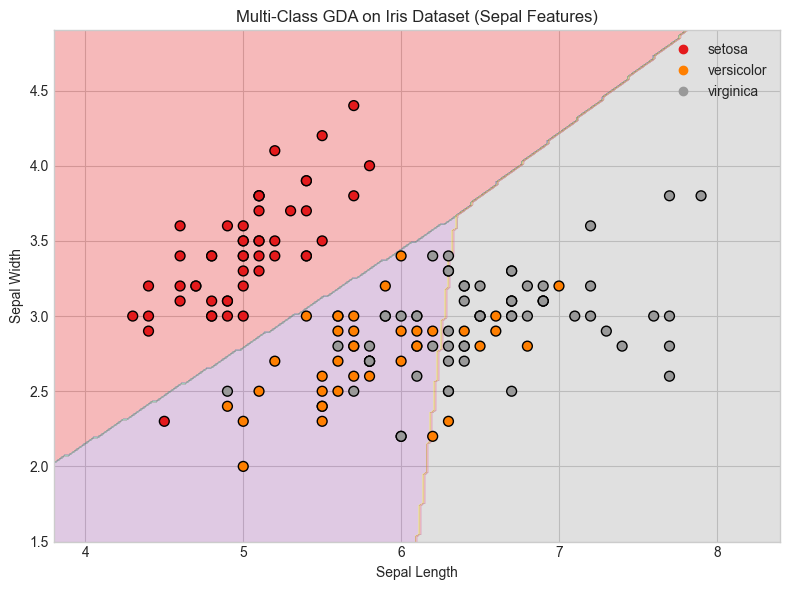

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# ==========================================
# 1. Define Multi-Class GDA
# ==========================================
class MultiClassGDA:
    def __init__(self):
        self.classes = None
        self.phi = {}
        self.mu = {}
        self.Sigma = None
        
    def fit(self, X, y):
        m, n = X.shape
        self.classes = np.unique(y)
        
        # Calculate priors (phi) and means (mu) for each class
        for c in self.classes:
            X_c = X[y == c]
            self.phi[c] = X_c.shape[0] / m
            self.mu[c] = np.mean(X_c, axis=0)
            
        # Calculate shared covariance matrix
        self.Sigma = np.zeros((n, n))
        for i in range(m):
            # Center the point using the mean of its specific class
            x_centered = (X[i] - self.mu[y[i]]).reshape(-1, 1)
            self.Sigma += x_centered @ x_centered.T
        self.Sigma /= m
        
        return self
        
    def _multivariate_gaussian(self, X, mu, Sigma):
        n = X.shape[1]
        Sigma_reg = Sigma + np.eye(n) * 1e-6
        det_Sigma = np.linalg.det(Sigma_reg)
        inv_Sigma = np.linalg.inv(Sigma_reg)
        
        diff = X - mu
        exponent = -0.5 * np.sum((diff @ inv_Sigma) * diff, axis=1)
        normalization = 1.0 / (((2 * np.pi) ** (n / 2)) * np.sqrt(det_Sigma))
        return normalization * np.exp(exponent)
        
    def predict(self, X):
        m = X.shape[0]
        num_classes = len(self.classes)
        # Store p(x|y=k) * p(y=k) for each class
        joint_probs = np.zeros((m, num_classes))
        
        for idx, c in enumerate(self.classes):
            p_x_given_y = self._multivariate_gaussian(X, self.mu[c], self.Sigma)
            joint_probs[:, idx] = p_x_given_y * self.phi[c]
            
        # The prediction is simply the class with the highest probability
        best_class_indices = np.argmax(joint_probs, axis=1)
        return np.array([self.classes[i] for i in best_class_indices])
        
    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

# ==========================================
# 2. Load Iris Data
# ==========================================
iris = load_iris()
X_iris = iris.data[:, :2]  # Using only sepal length and width for easy 2D plotting
y_iris = iris.target

print(f"Iris dataset: {X_iris.shape[0]} samples, {X_iris.shape[1]} features")
print(f"Classes: {iris.target_names}")
print(f"Class distribution: {np.bincount(y_iris)}")

# ==========================================
# 3. Binary Classification (Class 0 vs 1)
# ==========================================
mask = y_iris != 2  
X_binary = X_iris[mask]
y_binary = y_iris[mask]

gda_binary = MultiClassGDA().fit(X_binary, y_binary)
print(f"\nBinary GDA Accuracy: {gda_binary.accuracy(X_binary, y_binary):.4f}")

# ==========================================
# 4. Multi-Class Classification (All 3 Classes)
# ==========================================
gda_multi = MultiClassGDA().fit(X_iris, y_iris)
print(f"Multi-class GDA Accuracy: {gda_multi.accuracy(X_iris, y_iris):.4f}")

# ==========================================
# 5. Plotting the 3-Class Decision Boundary
# ==========================================
x_min, x_max = X_iris[:, 0].min() - 0.5, X_iris[:, 0].max() + 0.5
y_min, y_max = X_iris[:, 1].min() - 0.5, X_iris[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = gda_multi.predict(grid_points).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set1)
scatter = plt.scatter(X_iris[:, 0], X_iris[:, 1], c=y_iris, edgecolors='k', cmap=plt.cm.Set1, s=50)

plt.title("Multi-Class GDA on Iris Dataset (Sepal Features)")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend(handles=scatter.legend_elements()[0], labels=list(iris.target_names))
plt.tight_layout()
plt.show()

---
# Part 7: Key Takeaways

## Summary of Lecture 5

### Generative vs. Discriminative
- **Generative** models learn $p(x|y)$ and $p(y)$, use Bayes' rule for classification
- **Discriminative** models learn $p(y|x)$ directly
- Generative can be more data-efficient; discriminative is more robust

### Gaussian Discriminant Analysis (GDA)
- Assumes Gaussian class-conditionals with shared covariance
- **Closed-form MLE** — no iterative optimization needed!
- Shared $\Sigma$ → linear boundary; separate $\Sigma$ → quadratic boundary (QDA)
- GDA implies logistic regression, but not vice versa
- Better than logistic regression when: (1) data IS Gaussian, (2) small sample size

### Naive Bayes
- For discrete/binary features
- **Naive assumption:** features are conditionally independent given the class
- Despite being "naive," works surprisingly well in practice (especially for text)
- **Laplace smoothing** prevents zero probabilities
- Two event models: Multivariate Bernoulli (presence/absence) vs. Multinomial (word counts)

### When to Use What?

| Scenario | Recommended Model |
|----------|------------------|
| Continuous features, data looks Gaussian, small dataset | **GDA** |
| Continuous features, large dataset, unsure about distribution | **Logistic Regression** |
| Discrete/binary features (text, categorical) | **Naive Bayes** |
| Need probability estimates | Any of the above (all provide probabilities) |
| Multi-class with continuous features | Extend GDA or use Softmax Regression |

### The Generative Model Family Tree
```
Generative Models
├── Continuous features
│   ├── GDA (shared Σ → linear boundary)
│   └── QDA (separate Σ → quadratic boundary)
└── Discrete features
    ├── Naive Bayes (Bernoulli event model)
    └── Naive Bayes (Multinomial event model)
```

---
## References
- Stanford CS229: Machine Learning — Lecture 5 (Andrew Ng)
- [CS229 Lecture Notes](http://cs229.stanford.edu/main_notes.pdf)
- Bishop, *Pattern Recognition and Machine Learning*, Chapters 4.2-4.3